# Data gathering and preprocessing

## Imports

In [154]:
import kagglehub
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download latest version
kagglehub.dataset_download("jessemostipak/hotel-booking-demand", output_dir="./Dataset")
ds = pd.read_csv("./Dataset/hotel_bookings.csv").sample(10000, random_state=268555)

## Data checks

### Understanding given data

In [155]:
ds.info()

def printMissingDataSummary(ds):
    missingCount = ds.isna().sum()
    missingPercentage = (missingCount / len(ds) * 100).round(2)

    missingSummary = pd.DataFrame({
        "missingCount": missingCount,
        "missingPercentage": missingPercentage
    })

    print("\nMissing data summary:")
    print(missingSummary)

printMissingDataSummary(ds)

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 25367 to 93520
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           10000 non-null  object 
 1   is_canceled                     10000 non-null  int64  
 2   lead_time                       10000 non-null  int64  
 3   arrival_date_year               10000 non-null  int64  
 4   arrival_date_month              10000 non-null  object 
 5   arrival_date_week_number        10000 non-null  int64  
 6   arrival_date_day_of_month       10000 non-null  int64  
 7   stays_in_weekend_nights         10000 non-null  int64  
 8   stays_in_week_nights            10000 non-null  int64  
 9   adults                          10000 non-null  int64  
 10  children                        10000 non-null  float64
 11  babies                          10000 non-null  int64  
 12  meal                            1

### Dealing with missing data #1

In [156]:
ds.drop(columns=["company"], inplace=True)
ds = ds.loc[ds["country"].notna()].copy()
ds = ds.loc[ds["children"].notna()].copy()

### Dealing with strings in data (optional)

In [157]:
ds.describe(include="object")

for col in ds.select_dtypes(include=['object']).columns:
    if col != 'reservation_status_date':
        ds[col] = ds[col].astype('category').cat.codes
    else:
        ds["reservation_status_date"] = pd.to_datetime(ds["reservation_status_date"], errors="coerce")

ds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9957 entries, 25367 to 93520
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           9957 non-null   int8          
 1   is_canceled                     9957 non-null   int64         
 2   lead_time                       9957 non-null   int64         
 3   arrival_date_year               9957 non-null   int64         
 4   arrival_date_month              9957 non-null   int8          
 5   arrival_date_week_number        9957 non-null   int64         
 6   arrival_date_day_of_month       9957 non-null   int64         
 7   stays_in_weekend_nights         9957 non-null   int64         
 8   stays_in_week_nights            9957 non-null   int64         
 9   adults                          9957 non-null   int64         
 10  children                        9957 non-null   float64       
 11  babi

### Dealing with time in data

In [158]:
ds['arrival_date_month'] = ds['arrival_date_month'] + 1

ds['arrival_date'] = pd.to_datetime(
    ds['arrival_date_year'].astype(str) + '-' +
    ds['arrival_date_month'].astype(str) + '-' +
    ds['arrival_date_day_of_month'].astype(str),
    errors='coerce'
)

ds = ds[ds['arrival_date'].notna()].copy()

ds.drop(columns=['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month'], inplace=True)

### Dealing with orphans

In [159]:
ds = ds[ds['adults'] != 0]

### Dealing with missing data #2

In [160]:
trainDf = ds[ds["agent"].notna()].copy()
predictDf = ds[ds["agent"].isna()].copy()

y = trainDf["agent"]
X = trainDf.drop(columns=["agent"])
predX = predictDf.drop(columns=["agent"])

catCols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numCols = X.select_dtypes(include=["number"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", sklearn.preprocessing.OneHotEncoder(handle_unknown="ignore"), catCols),
        ("num", "passthrough", numCols),
    ]
)

model = sklearn.pipeline.Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=268555))
])

trainX, valX, trainY, valY = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=268555)

model.fit(trainX, trainY)
print("val score:", model.score(valX, valY))

predictedAgents = model.predict(predX)

ds.loc[ds["agent"].isna(), "agent"] = predictedAgents

val score: 0.821301775147929


In [161]:
printMissingDataSummary(ds)


Missing data summary:
                                missingCount  missingPercentage
hotel                                      0                0.0
is_canceled                                0                0.0
lead_time                                  0                0.0
arrival_date_week_number                   0                0.0
stays_in_weekend_nights                    0                0.0
stays_in_week_nights                       0                0.0
adults                                     0                0.0
children                                   0                0.0
babies                                     0                0.0
meal                                       0                0.0
country                                    0                0.0
market_segment                             0                0.0
distribution_channel                       0                0.0
is_repeated_guest                          0                0.0
previous_cancella

In [162]:
def printColumnValueCounts(ds):
    print(ds.nunique(dropna=False))

    rows = []
    for col in ds.columns:
        counts = ds[col].value_counts(dropna=False).sort_values(ascending=False)
        for val, cnt in counts.items():
            rows.append({
                "column": col,
                "value": str(val),
                "count": cnt
            })

    result = pd.DataFrame(rows)
    result.to_csv("column_value_counts.csv", index=False, encoding="utf-8-sig")
    print("Wrote", len(result), "rows to column_value_counts.csv")

printColumnValueCounts(ds)

hotel                                2
is_canceled                          2
lead_time                          436
arrival_date_week_number            53
stays_in_weekend_nights             11
stays_in_week_nights                23
adults                               4
children                             4
babies                               3
meal                                 5
country                            111
market_segment                       7
distribution_channel                 4
is_repeated_guest                    2
previous_cancellations              12
previous_bookings_not_canceled      29
reserved_room_type                   8
assigned_room_type                  10
booking_changes                      9
deposit_type                         3
agent                              216
days_in_waiting_list                85
customer_type                        4
adr                               2134
required_car_parking_spaces          3
total_of_special_requests

### Correlation matrix presentation

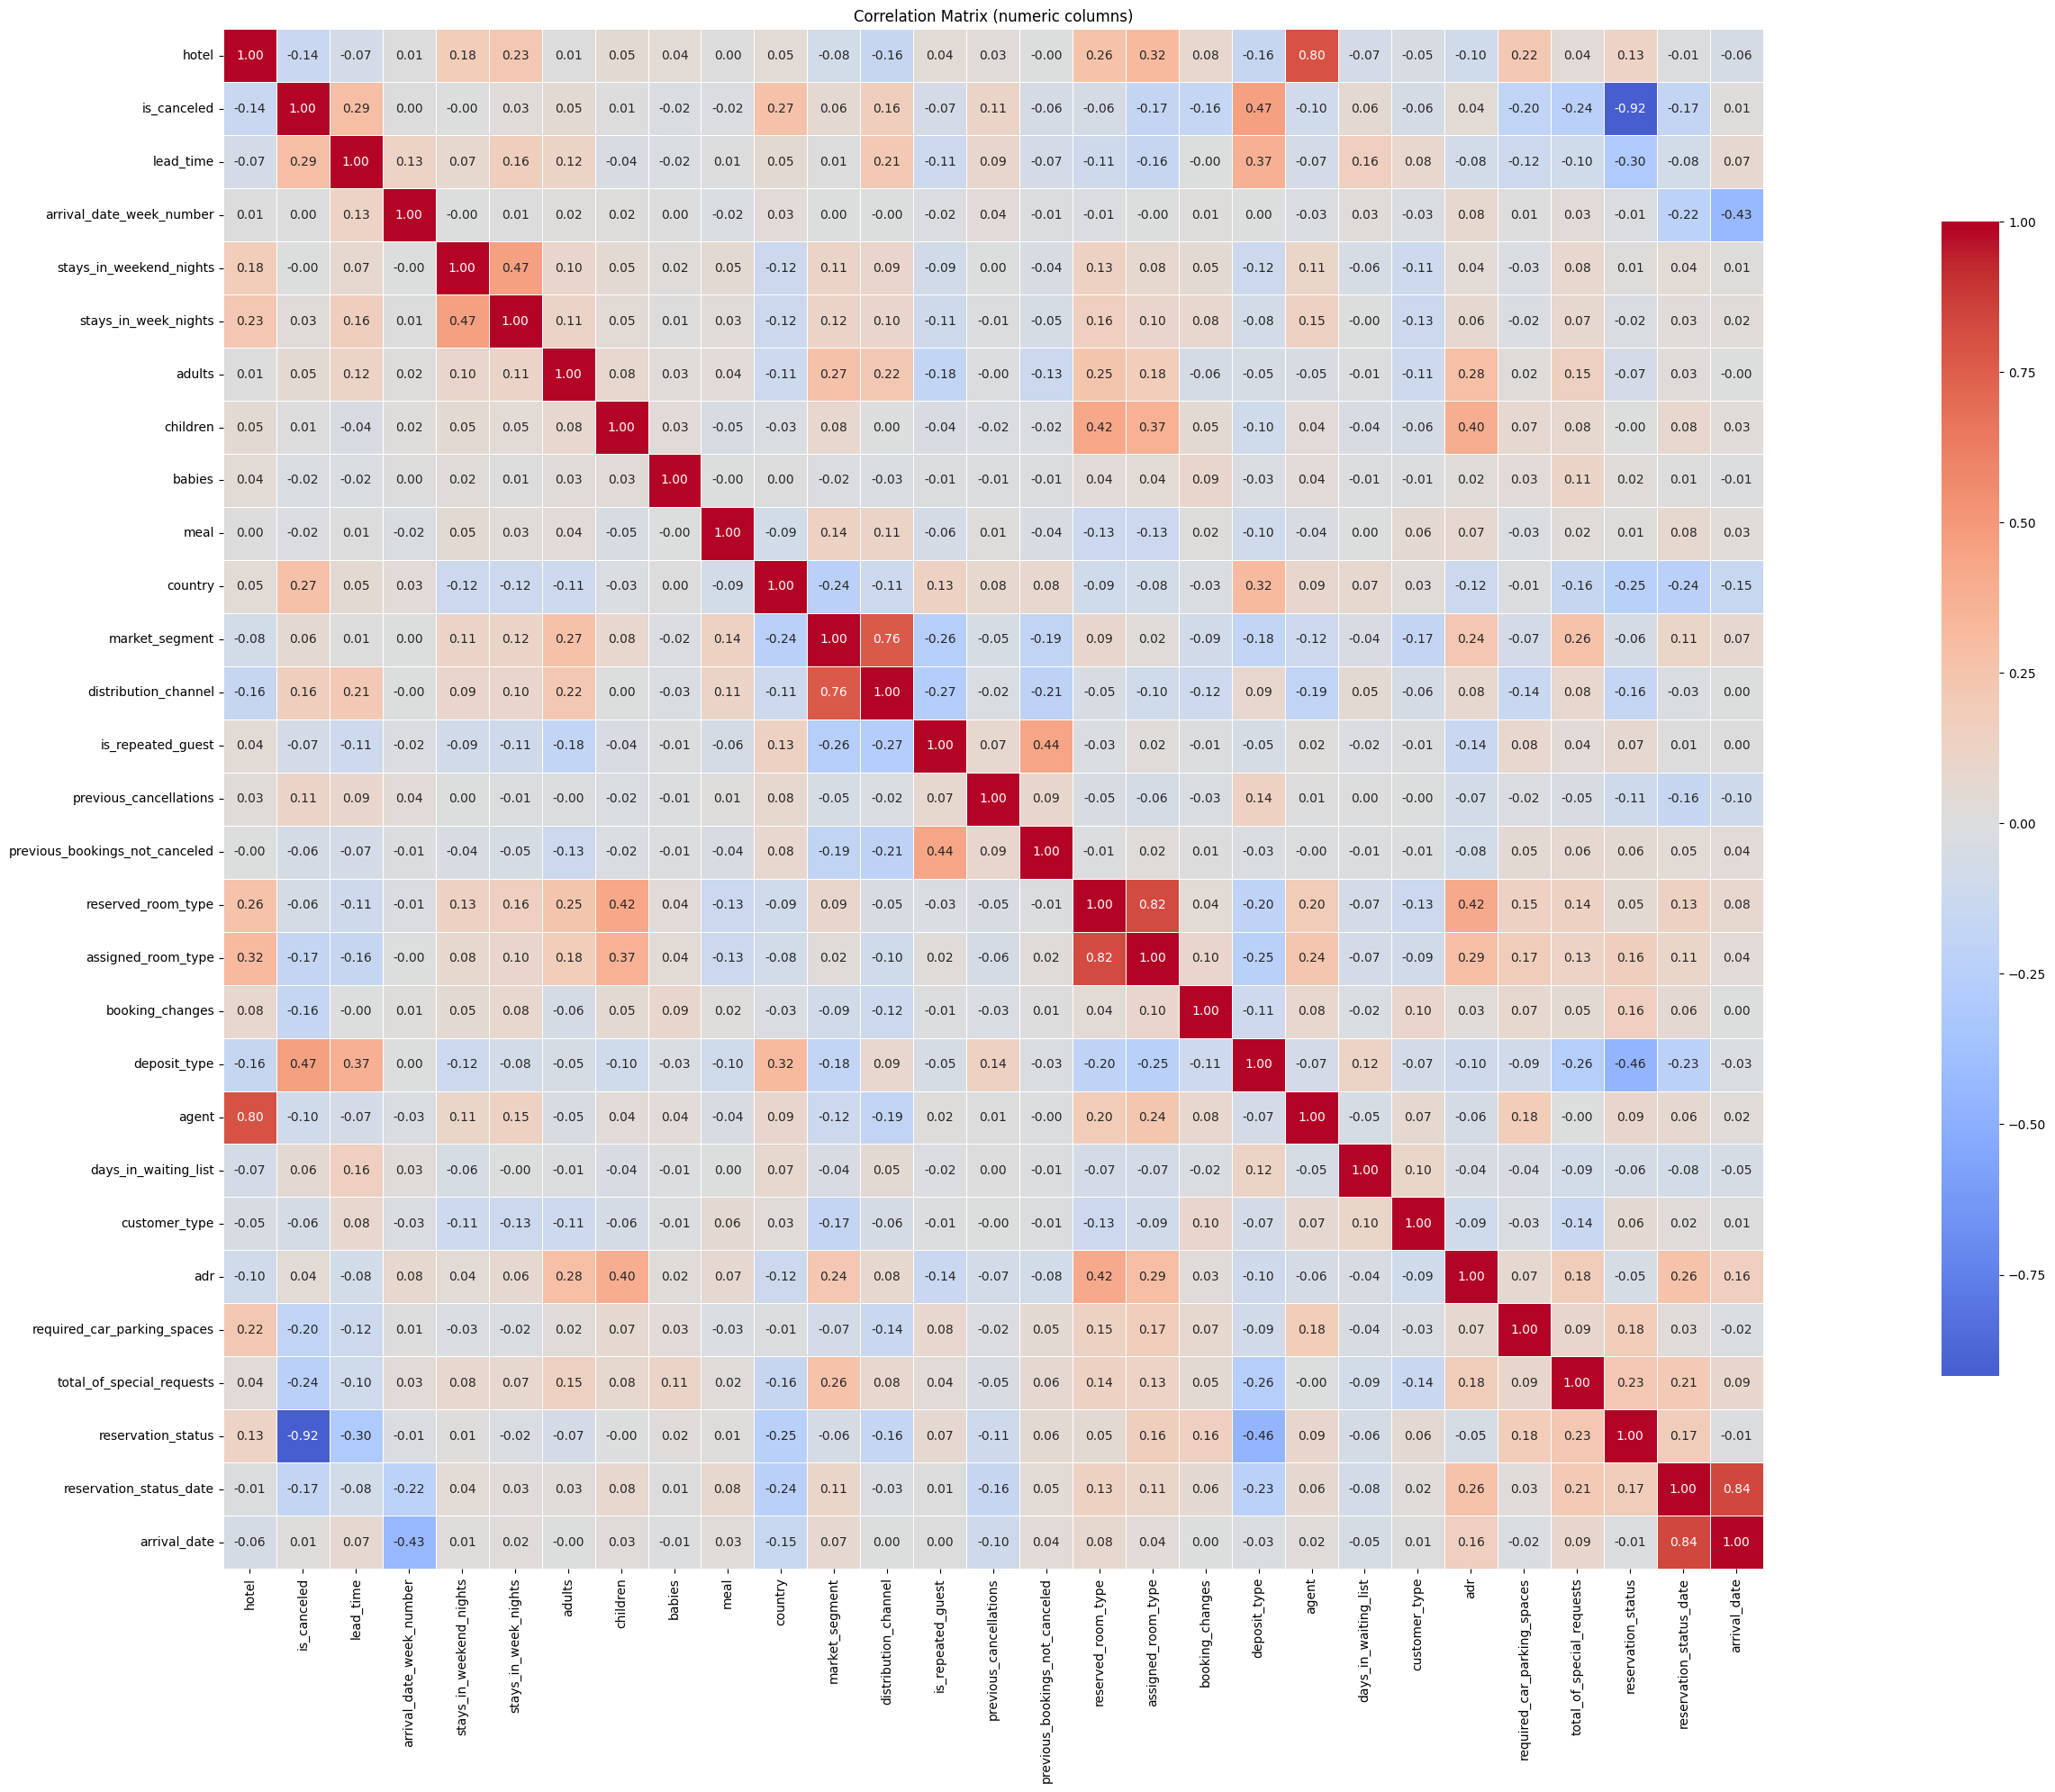

In [163]:
def printComputationMatrix(ds):
    corr = ds.corr()

    plt.figure(figsize=(40, 20))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.75}
    )
    plt.title("Correlation Matrix (numeric columns)")
    plt.tight_layout()
plt.show()


printComputationMatrix(ds)

In [164]:
def top_correlations(ds, n=100):
    corr = ds.corr()

    corr_long = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))  # keep upper triangle
        .stack()
        .reset_index()
    )

    corr_long.columns = ["var1", "var2", "correlation"]
    corr_long["abs_corr"] = corr_long["correlation"].abs()

    print(corr_long.sort_values("abs_corr", ascending=False).head(n).to_string(index=False))

top_correlations(ds)

                       var1                           var2  correlation  abs_corr
                is_canceled             reservation_status    -0.918945  0.918945
    reservation_status_date                   arrival_date     0.838773  0.838773
         reserved_room_type             assigned_room_type     0.823823  0.823823
                      hotel                          agent     0.799783  0.799783
             market_segment           distribution_channel     0.763152  0.763152
    stays_in_weekend_nights           stays_in_week_nights     0.466685  0.466685
                is_canceled                   deposit_type     0.465482  0.465482
               deposit_type             reservation_status    -0.464256  0.464256
          is_repeated_guest previous_bookings_not_canceled     0.439153  0.439153
   arrival_date_week_number                   arrival_date    -0.425684  0.425684
                   children             reserved_room_type     0.423613  0.423613
         reserve

### ADR Plots

C:\Users\Roch\AppData\Local\Temp\ipykernel_20088\1660737143.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hotel_1_quarterly = hotel_1.groupby('quarter')[ds.columns[23]].mean()
C:\Users\Roch\AppData\Local\Temp\ipykernel_20088\1660737143.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hotel_0_quarterly = hotel_0.groupby('quarter')[ds.columns[23]].mean()
C:\Users\Roch\AppData\Local\Temp\ipykernel_20088\1660737143.py:107: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(

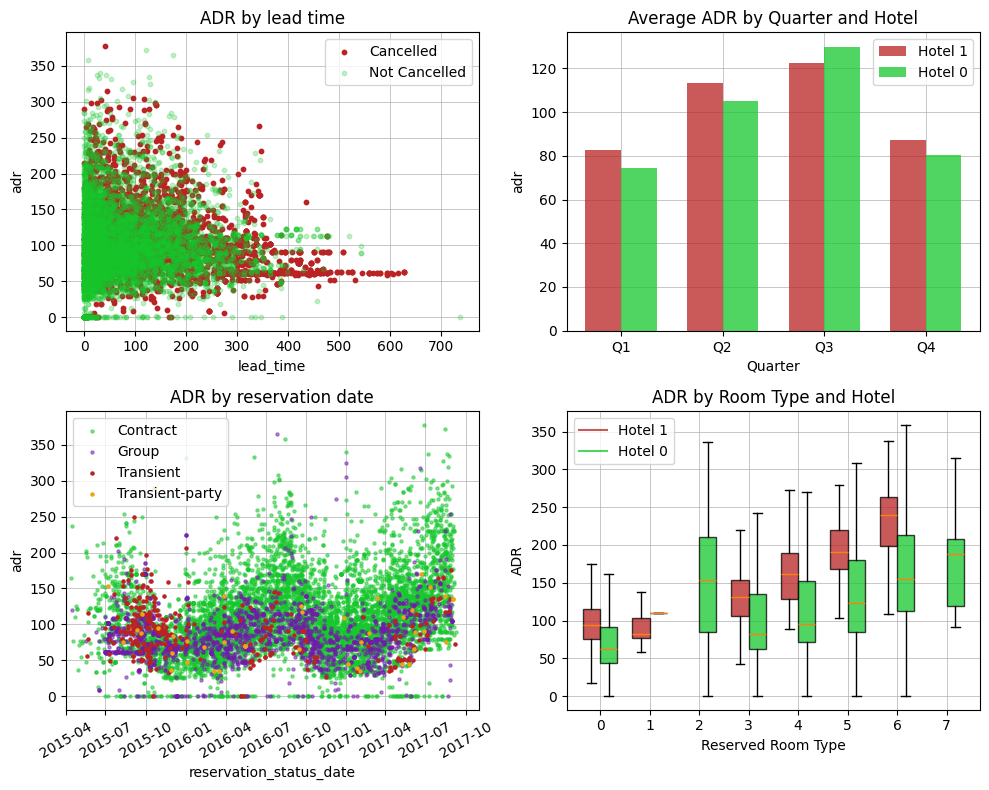

In [165]:
from matplotlib import axes, colors


def printADRPlots(valX):
    fig, axes = plt.subplots(2, 2, figsize=(10,8))
    
    # is expensive early booking a cancalltion risk?
    #-----------------------------------------------------
    # split data by cancellation
    cancelled = ds[ds.iloc[:,1] == 1]
    not_cancelled = ds[ds.iloc[:,1] == 0]

    # scatter plots with labels
    axes[0,0].scatter(cancelled.iloc[:,2], cancelled.iloc[:,23], 
                      label='Cancelled', c='#B92323', alpha = 1, s=10)
    axes[0,0].scatter(not_cancelled.iloc[:,2], not_cancelled.iloc[:,23],
                      label='Not Cancelled', c="#16C72D", alpha = 0.25, s=10)
    axes[0,0].set_xlabel(ds.columns[2]) # lead time
    axes[0,0].set_ylabel(ds.columns[23]) # adr
    axes[0,0].set_title("ADR by lead time")
    axes[0,0].legend()
    axes[0,0].grid(True, linewidth = 0.5)
    axes[0,0].set_axisbelow(True)
    #------------------------------------------------------
    # do peak-season customers pay more? OLD VERSION, REPLACED BY QUARTERLY BAR CHART BELOW
    #------------------------------------------------------
    # hotel_1 = ds[ds.iloc[:,1] == 1]
    # hotel_0 = ds[ds.iloc[:,1] == 0]
    # # scatter plots with labels
    # axes[0,1].scatter(hotel_1.iloc[:,3], hotel_1.iloc[:,23], 
    #                   label='Hotel 1', c='#DB5C44', alpha = 0.75, s=15)
    # axes[0,1].scatter(hotel_0.iloc[:,3], hotel_0.iloc[:,23],
    #                   label='Hotel 0', c='#4465DB', alpha = 0.25, s=15)
    # axes[0,1].set_xlabel(ds.columns[3]) # arrival_date_week_number
    # plt.setp(axes[0,1].get_xticklabels(), rotation=0)
    # axes[0,1].set_ylabel(ds.columns[23]) # adr
    # axes[0,1].set_title("ADR by arrival week number")
    # axes[0,1].legend()
    # axes[0,1].grid(True, linewidth = 0.5)
    # axes[0,1].set_axisbelow(True)
    #------------------------------------------------------
    # create quarter from week number
    ds.iloc[:,3] = pd.to_numeric(ds.iloc[:,3], errors='coerce')

    # create quarter
    ds['quarter'] = pd.cut(
        ds.iloc[:,3],
        bins=[0,13,26,39,52],
        labels=['Q1','Q2','Q3','Q4']
    )

    # recompute hotel splits (important after adding column)
    hotel_1 = ds[ds.iloc[:,1] == 1]
    hotel_0 = ds[ds.iloc[:,1] == 0]

    # group by quarter
    hotel_1_quarterly = hotel_1.groupby('quarter')[ds.columns[23]].mean()
    hotel_0_quarterly = hotel_0.groupby('quarter')[ds.columns[23]].mean()

    # Combine into one DataFrame
    df_quarterly = pd.DataFrame({
        "Hotel 1": hotel_1_quarterly,
        "Hotel 0": hotel_0_quarterly
    })
    df_quarterly = df_quarterly.sort_index()

    # Bar chart positions
    x = np.arange(len(df_quarterly))  # one per quarter
    width = 0.35  # width of bars
    # Plot side-by-side bars
    axes[0,1].bar(x - width/2, df_quarterly["Hotel 1"], width, label="Hotel 1", color="#B92323", alpha=0.75)
    axes[0,1].bar(x + width/2, df_quarterly["Hotel 0"], width, label="Hotel 0", color="#16C72D", alpha=0.75)

    # Labels and title
    axes[0,1].set_xticks(x)
    axes[0,1].set_xticklabels(
    df_quarterly.index,
    rotation=0
    )
    axes[0,1].set_xlabel("Quarter")
    axes[0,1].set_ylabel(ds.columns[23])  # ADR
    axes[0,1].set_title("Average ADR by Quarter and Hotel")
    axes[0,1].legend()
    axes[0,1].grid(True, linewidth=0.5)
    axes[0,1].set_axisbelow(True)

    # do customers who book earlier pay less?
    #------------------------------------------------------
    customer_type_0 = ds[ds.iloc[:,22] == 0]
    customer_type_1 = ds[ds.iloc[:,22] == 1]
    customer_type_2 = ds[ds.iloc[:,22] == 2]
    customer_type_3 = ds[ds.iloc[:,22] == 3]

    # scatter plots with labels
    axes[1,0].scatter(customer_type_2.iloc[:,27], customer_type_2.iloc[:,23],
                      label='Contract', c="#16C72D", alpha = 0.5, s=5)
    axes[1,0].scatter(customer_type_3.iloc[:,27], customer_type_3.iloc[:,23], 
                      label='Group', c="#711CAA", alpha = 0.5, s=5)
    axes[1,0].scatter(customer_type_0.iloc[:,27], customer_type_0.iloc[:,23], 
                      label='Transient', c="#B92323", alpha = 1, s=5)
    axes[1,0].scatter(customer_type_1.iloc[:,27], customer_type_1.iloc[:,23],
                      label='Transient-party', c="#EBA613", alpha = 1, s=5)
    
    
    axes[1,0].set_xlim(left=pd.Timestamp('2015-04-01'))
    axes[1,0].set_xlabel(ds.columns[27]) # 
    axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=30)
    axes[1,0].set_ylabel(ds.columns[23]) # adr
    axes[1,0].set_title("ADR by reservation date")
    axes[1,0].legend()
    axes[1,0].grid(True, linewidth = 0.5)
    axes[1,0].set_axisbelow(True)
    #------------------------------------------------------

    

    # How much do people pay for specific rooms?
    #------------------------------------------------------
    room_types = sorted(ds[ds.columns[16]].unique())  # all room types
    hotels = sorted(ds[ds.columns[0]].unique())       # all hotels
    width = 0.35  # width of each box
    x = np.arange(len(room_types))  # positions for room types

    # swapped colors: Hotel 1 = blue, Hotel 0 = red
    colors = ['#B92323', '#16C72D']
    alpha = 0.75

    for i, hotel in enumerate(hotels):
        # prepare data for all room types for this hotel
        data_to_plot = [
            ds[(ds[ds.columns[16]] == room) & (ds[ds.columns[0]] == hotel)][ds.columns[23]]
            for room in room_types
        ]
        # positions offset for side-by-side boxes
        positions = x - width/2 + i*width
        
        # plot boxplot
        bplot = axes[1,1].boxplot(data_to_plot, positions=positions, widths=width,
                                patch_artist=True, showfliers=False)
        
        # color the boxes
        for patch in bplot['boxes']:
            patch.set_facecolor(colors[i])
            patch.set_alpha(alpha)

    # x-axis labels
    axes[1,1].set_xticks(x)
    axes[1,1].set_xticklabels(room_types, rotation=0)
    axes[1,1].set_xlabel("Reserved Room Type")
    axes[1,1].set_ylabel("ADR")
    axes[1,1].set_title("ADR by Room Type and Hotel")
    axes[1,1].grid(True, linewidth=0.5)
    axes[1,1].set_axisbelow(True)

    # custom legend with explicit hotel names
    legend_labels = ["Hotel 1", "Hotel 0"]
    for i, label in enumerate(legend_labels):
        axes[1,1].plot([], [], color=colors[i], alpha=alpha, label=label)
    axes[1,1].legend()
    #------------------------------------------------------

    plt.tight_layout()
    plt.show()

printADRPlots(ds)

C:\Users\Roch\AppData\Local\Temp\ipykernel_20088\2453567441.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key=cancelled.columns[27], freq='M')
C:\Users\Roch\AppData\Local\Temp\ipykernel_20088\2453567441.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key=not_cancelled.columns[27], freq='M')
C:\Users\Roch\AppData\Local\Temp\ipykernel_20088\2453567441.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=30)


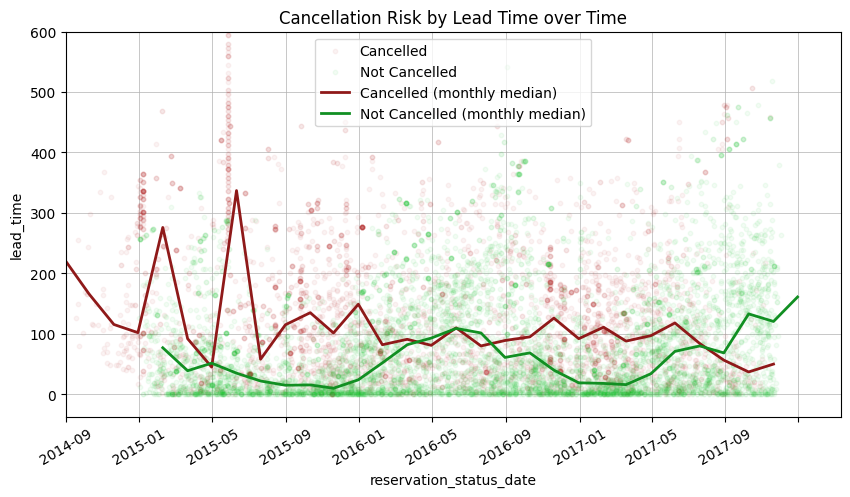

In [166]:
def printLinePlots(ds):
    fig, axes = plt.subplots(1, 1, figsize=(10,5), squeeze=False)
    cancelled = ds[ds.iloc[:,1] == 1]
    not_cancelled = ds[ds.iloc[:,1] == 0]
    # is long lead time a cancellation risk?
    #------------------------------------------------------
    # grouping split
    cancelled_monthly = cancelled.groupby(
    pd.Grouper(key=cancelled.columns[27], freq='M')
    )[cancelled.columns[2]].median()

    not_cancelled_monthly = not_cancelled.groupby(
        pd.Grouper(key=not_cancelled.columns[27], freq='M')
    )[not_cancelled.columns[2]].median()
    cancelled_monthly = cancelled_monthly.sort_index()
    not_cancelled_monthly = not_cancelled_monthly.sort_index()
    cancelled_median = cancelled.groupby(cancelled.iloc[:,27])[cancelled.columns[2]].median()
    not_cancelled_median = not_cancelled.groupby(not_cancelled.iloc[:,27])[not_cancelled.columns[2]].median()

    # scatter plots with labels
    axes[0,0].scatter(cancelled.iloc[:,27], cancelled.iloc[:,2], 
                      label='Cancelled', c='#B92323', alpha = 0.05, s=10)
    axes[0,0].scatter(not_cancelled.iloc[:,27], not_cancelled.iloc[:,2],
                      label='Not Cancelled', c='#16C72D', alpha = 0.05, s=10)

    axes[0,0].plot(cancelled_monthly.index, cancelled_monthly.values,
               color="#8F1919", linewidth=2, label='Cancelled (monthly median)')

    axes[0,0].plot(not_cancelled_monthly.index, not_cancelled_monthly.values,
               color="#118F22", linewidth=2, label='Not Cancelled (monthly median)')
    axes[0,0].set_xlabel(ds.columns[27]) # reservation_status_date
    axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=30)
    axes[0,0].set_xlim(left=pd.Timestamp('2015-04-01'))
    axes[0,0].set_ylim(top=600)
    axes[0,0].set_ylabel(ds.columns[2]) # lead_time
    axes[0,0].set_title("Cancellation Risk by Lead Time over Time")
    axes[0,0].legend()
    axes[0,0].grid(True, linewidth = 0.5)
    axes[0,0].set_axisbelow(True)
    #------------------------------------------------------

printLinePlots(ds)